In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Unemployment in India.csv")

In [9]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [13]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [15]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [17]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [19]:
df.dropna(inplace=True)

In [21]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [25]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [29]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [31]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [33]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\mamun\AppData\Local\Temp\ipykernel_15744\2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [35]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d-%m-%Y'
)

# Unemployment Rate Distribution

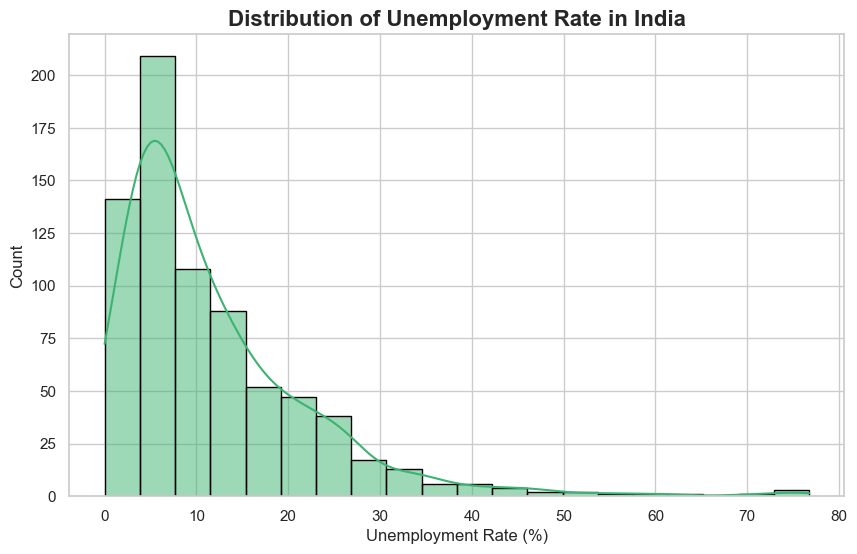

In [61]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True,
    color='mediumseagreen',
    edgecolor='black'
)

plt.title(
    "Distribution of Unemployment Rate in India",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")

plt.savefig(
    "unemployment_distribution_hd.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Top 10 States by Average Unemployment Rate

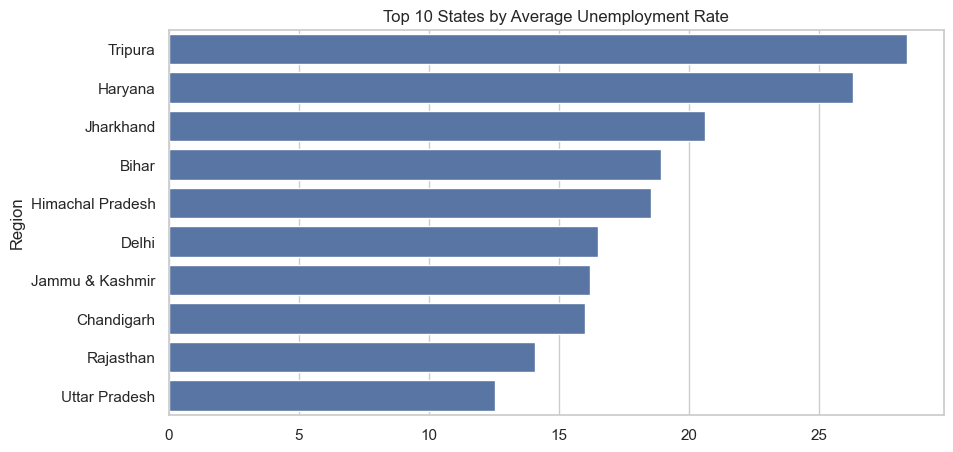

In [59]:
top_states = (
    df.groupby('Region')
    ['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Average Unemployment Rate")

plt.savefig(
    "top10_states_hd.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Rural vs Urban Analysis

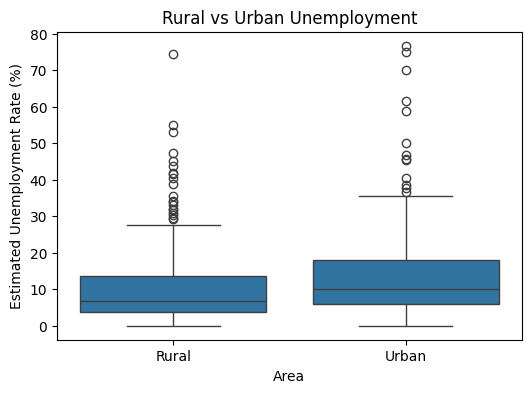

In [44]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Rural vs Urban Unemployment")

plt.savefig(
    "rural_vs_urban_hd.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Covid Impact Analysis

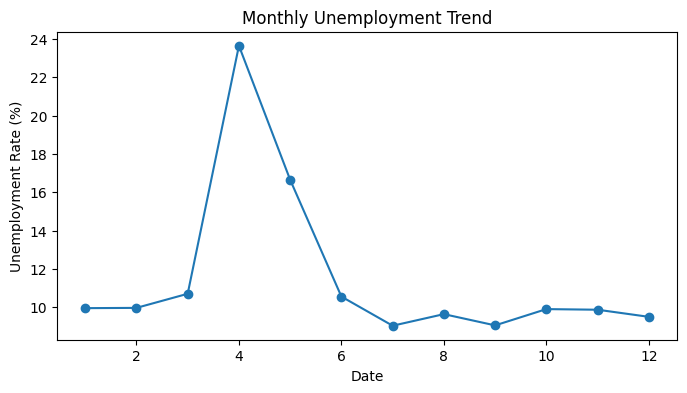

In [47]:
monthly = df.groupby(
    df['Date'].dt.month
)['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(8,4))

monthly.plot(marker='o')

plt.title("Monthly Unemployment Trend")

plt.ylabel("Unemployment Rate (%)")

plt.savefig(
    "monthly_trend_hd.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Correlation Heatmap

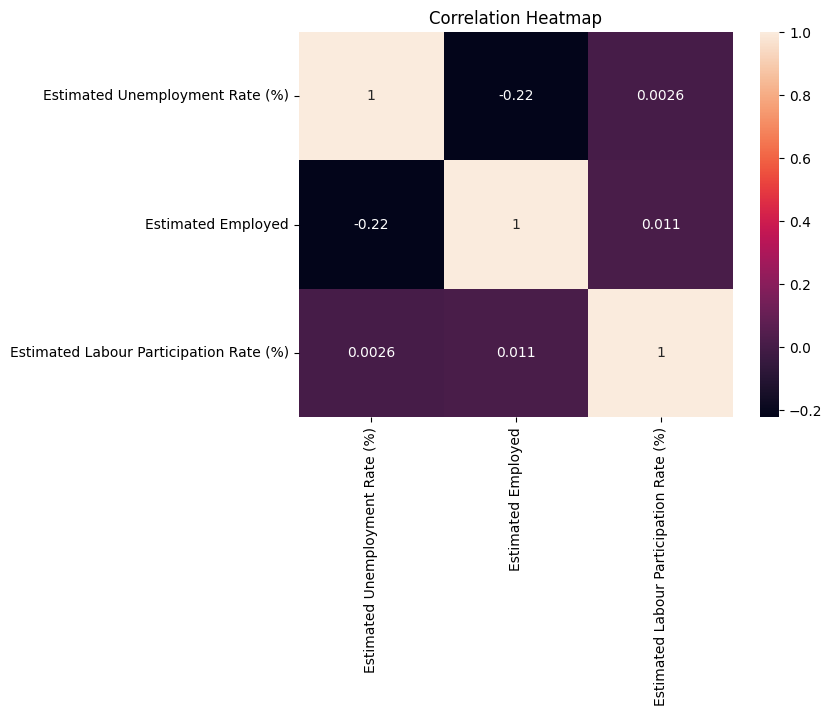

In [50]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.savefig(
    "correlation_heatmap_hd.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

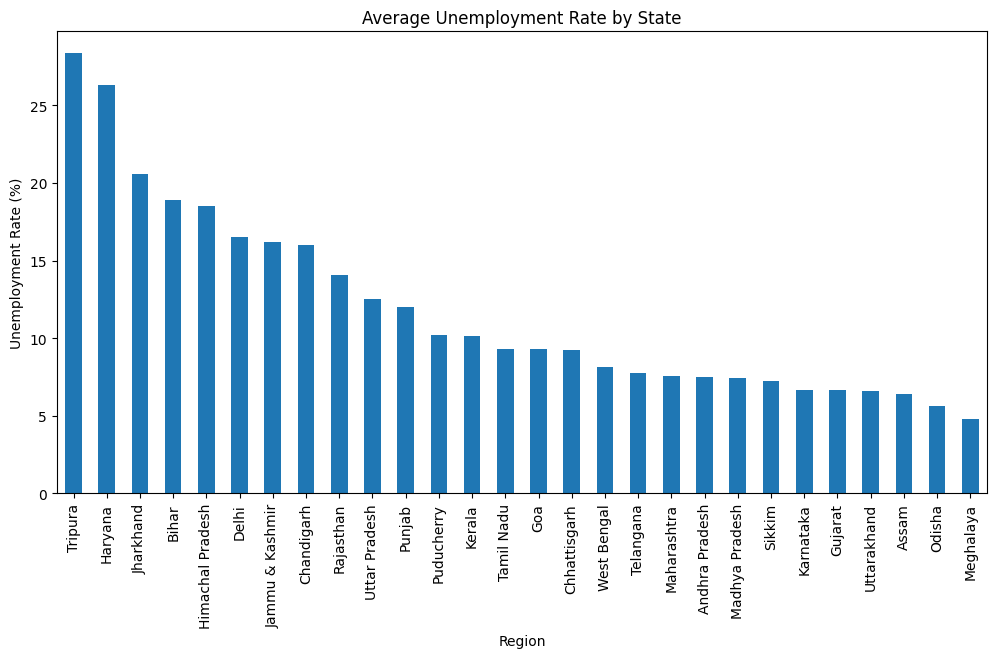

In [53]:
plt.figure(figsize=(12,6))

state_unemployment = (
    df.groupby('Region')
    ['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

state_unemployment.plot(kind='bar')

plt.title("Average Unemployment Rate by State")
plt.ylabel("Unemployment Rate (%)")

plt.savefig(
    "state_wise_unemployment_hd.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()